# <span style="color:#1B4F72;">RNN Project Pipeline</span>

**Business Understanding**  
↓  
**Data Collection**  
↓  
**Dataset Understanding**  
> Check **sequence length, sampling rate, and ordering**

↓  
**Data Cleaning**  
↓  
**Handle Missing Values**  
> Time Series → **Interpolation / Forward-fill**  
> **NOT random imputation — order matters!**

↓  
**Handle Outliers** *(if required)*  
↓  
**Exploratory Data Analysis (EDA)**  
> Time Series → Plot sequences over time, autocorrelation, trend/seasonality  
> Text → Token/word frequency

↓  
**Feature Engineering** *(if required)*  
> Time Series → Lag features, rolling statistics  
> Text → Tokenization, vocabulary building

↓  
**Define Features (X) and Target (y)**  
↓  
**Create Sequences (Windowing)**  
> Slice data into **fixed-length sequences**  
>
> Example:  
> `Past 30 days → Predict Day 31`  
> `Sentence → Pad/Truncate → max_len`

↓  
**Train-Validation-Test Split**  
> Time Series → **Chronological split**  
> No random shuffling → prevents **future-to-past data leakage**  
> Text → Can still shuffle

↓  
**Encoding**  
> Time Series → Label Encoding  
> Text → Tokenization + Vocabulary/Embedding Index

↓  
**Feature Scaling**  
> Time Series → MinMax / Standard Scaling  
> Text → Usually skipped; embeddings handle representation

↓  
**Convert to Tensors**

```text
Traditional:
(batch, features)

RNN:
(batch, seq_len, features)
```

↓  
**Create Dataset & DataLoader**  
> Variable-length sequences may require **padding / collate_fn**

↓  
**Design RNN Architecture**  
> Choose **RNN / LSTM / GRU**  
> Decide: `hidden_size`, `num_layers`, `bidirectional`

↓  
**Train the Model**  
> Watch for **vanishing/exploding gradients**  
> Consider **gradient clipping**

↓  
**Evaluate the Model**  
> Time Series → **RMSE / MAE**  
> Text → **Accuracy / F1 / Perplexity**

↓  
**Save Model & Artifacts**  
> Save model weights along with required artifacts such as **tokenizer/vocab or scaler**

In [1]:
import pandas as pd
import numpy as np 

In [2]:
df = pd.read_csv(r"C:\Users\rohit\Downloads\AI and Data Science\𝗗𝗲𝗲𝗽 𝗟𝗲𝗮𝗿𝗻𝗶𝗻𝗴 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\RNN Projects\New folder\data\1_Daily_minimum_temps.csv")

df.head()

df.drop('Date', axis=1, inplace=True)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Temp    3650 non-null   str  
dtypes: str(1)
memory usage: 40.5 KB


In [4]:
df.drop(df[df['Temp'] == '?0.2'].index, inplace=True)

In [5]:
#Dropping any row contain a question mark

df = df[~df.astype(str).apply(lambda row: row.str.contains(r'\?').any(), axis=1)]

In [6]:
df['Temp'] = df['Temp'].astype(float)

In [7]:
df.describe()

,Temp
count,3647.000000
mean,11.186647
std,4.061671
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


In [8]:
df.isnull().sum()

Temp    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(3420)

In [10]:
df

,Temp
0,20.7
1,17.9
2,18.8
3,14.6
4,15.8
...,...
3645,14.0
3646,13.6
3647,13.5
3648,15.7


In [11]:
#preparing temp data 

temperatures = df['Temp'].values

print(temperatures[:10])
print(type(temperatures))
print(temperatures.shape)

[20.7 17.9 18.8 14.6 15.8 15.8 15.8 17.4 21.8 20. ]
<class 'numpy.ndarray'>
(3647,)


In [12]:
#train - test - validation 

n = len(temperatures)

train_size = int(n * 0.70)
val_size = int(n * 0.15)

train_data = temperatures[:train_size]

val_data = temperatures[
    train_size:train_size + val_size
]

test_data = temperatures[
    train_size + val_size:
]

print("Total :", len(temperatures))
print("Train :", len(train_data))
print("Val   :", len(val_data))
print("Test  :", len(test_data))

Total : 3647
Train : 2552
Val   : 547
Test  : 548


In [13]:
n

3647

In [14]:
#scaling data

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train_data.reshape(-1, 1)
)

val_scaled = scaler.transform(
    val_data.reshape(-1, 1)
)

test_scaled = scaler.transform(
    test_data.reshape(-1, 1)
)

In [17]:
sequence_length = 30
def create_sequences(data, sequence_length):

    X = []
    y = []

    for i in range(len(data) - sequence_length):#Data ke andar window ko move karne ke liye loop chalao, jitni baar complete input sequence + target ban sakta hai.

        X.append(
            data[i:i + sequence_length]         #Current i se start karke sequence_length jitni values uthao aur X mein store karo.
        )

        y.append(
            data[i + sequence_length]
        )

    return np.array(X), np.array(y)

In [18]:
X_train, y_train = create_sequences(
    train_scaled,
    sequence_length
)

X_val, y_val = create_sequences(
    val_scaled,
    sequence_length
)

X_test, y_test = create_sequences(
    test_scaled,
    sequence_length
)

In [20]:
import torch
X_train = torch.tensor(X_train, dtype=torch.float32)

X_train.shape

torch.Size([2522, 30, 1])

In [21]:
y_train = torch.tensor(y_train, dtype=torch.float32)

y_train.shape

torch.Size([2522, 1])

In [22]:
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [23]:
#now creating dataset and dataloader 

from torch.utils.data import TensorDataset, DataLoader

# =========================
# Create Datasets
# =========================

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)


# =========================
# Create DataLoaders
# =========================

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [24]:
for X_batch, y_batch in train_loader:
    print("X Batch:", X_batch.shape)
    print("y Batch:", y_batch.shape)
    break

X Batch: torch.Size([32, 30, 1])
y Batch: torch.Size([32, 1])


In [25]:
import torch.nn as nn


class TemperatureRNN(nn.Module):

    def __init__(self, input_size=1, hidden_size=64, num_layers=1):

        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)


    def forward(self, x):

        out, hidden = self.rnn(x)

        # Last time-step output
        out = out[:, -1, :]

        # Predict next temperature
        out = self.fc(out)

        return out

In [27]:
model = TemperatureRNN(
    input_size=1,
    hidden_size=64,
    num_layers=1
)

print(model)

TemperatureRNN(
  (rnn): RNN(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [28]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [29]:
num_epochs = 15

train_losses = []
val_losses = []


for epoch in range(num_epochs):

    # =====================
    # Training
    # =====================

    model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        predictions = model(X_batch)

        # Calculate loss
        loss = criterion(
            predictions,
            y_batch
        )

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # =====================
    # Validation
    # =====================

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            val_loss += loss.item()

    val_loss /= len(val_loader)


    train_losses.append(train_loss)
    val_losses.append(val_loss)


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.6f} "
        f"| Val Loss: {val_loss:.6f}"
    )

Epoch [1/15] | Train Loss: 0.022327 | Val Loss: 0.013006
Epoch [2/15] | Train Loss: 0.011858 | Val Loss: 0.010146
Epoch [3/15] | Train Loss: 0.010773 | Val Loss: 0.009466
Epoch [4/15] | Train Loss: 0.009993 | Val Loss: 0.010030
Epoch [5/15] | Train Loss: 0.009692 | Val Loss: 0.010996
Epoch [6/15] | Train Loss: 0.009620 | Val Loss: 0.008384
Epoch [7/15] | Train Loss: 0.009408 | Val Loss: 0.008387
Epoch [8/15] | Train Loss: 0.009055 | Val Loss: 0.008520
Epoch [9/15] | Train Loss: 0.009093 | Val Loss: 0.008280
Epoch [10/15] | Train Loss: 0.008981 | Val Loss: 0.008114
Epoch [11/15] | Train Loss: 0.008855 | Val Loss: 0.008105
Epoch [12/15] | Train Loss: 0.009152 | Val Loss: 0.009414
Epoch [13/15] | Train Loss: 0.009130 | Val Loss: 0.008189
Epoch [14/15] | Train Loss: 0.008920 | Val Loss: 0.008507
Epoch [15/15] | Train Loss: 0.009078 | Val Loss: 0.008413


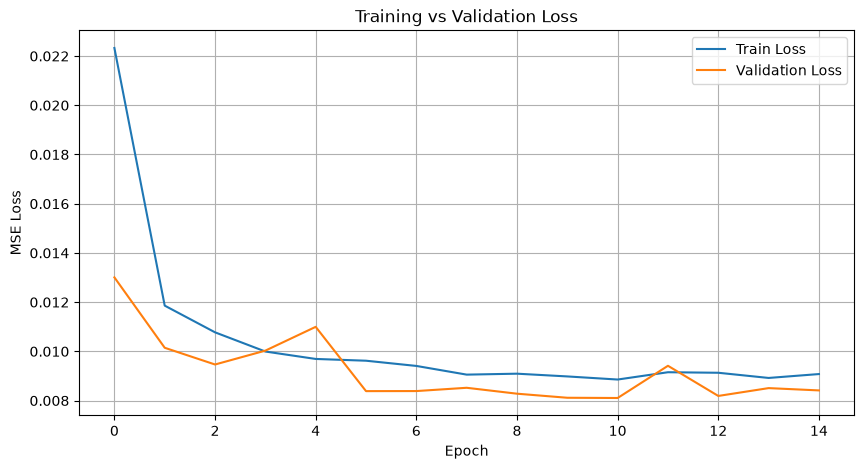

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model.eval()

predictions = []
actuals = []


with torch.no_grad():

    for X_batch, y_batch in test_loader:

        output = model(X_batch)

        predictions.extend(
            output.squeeze().numpy()
        )

        actuals.extend(
            y_batch.squeeze().numpy()
        )


predictions = np.array(predictions)
actuals = np.array(actuals)

In [32]:
predictions_actual = scaler.inverse_transform(
    predictions.reshape(-1, 1)
).flatten()

actuals_actual = scaler.inverse_transform(
    actuals.reshape(-1, 1)
).flatten()

In [33]:
mae = mean_absolute_error(
    actuals_actual,
    predictions_actual
)

rmse = np.sqrt(
    mean_squared_error(
        actuals_actual,
        predictions_actual
    )
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

MAE  : 1.7773
RMSE : 2.2804


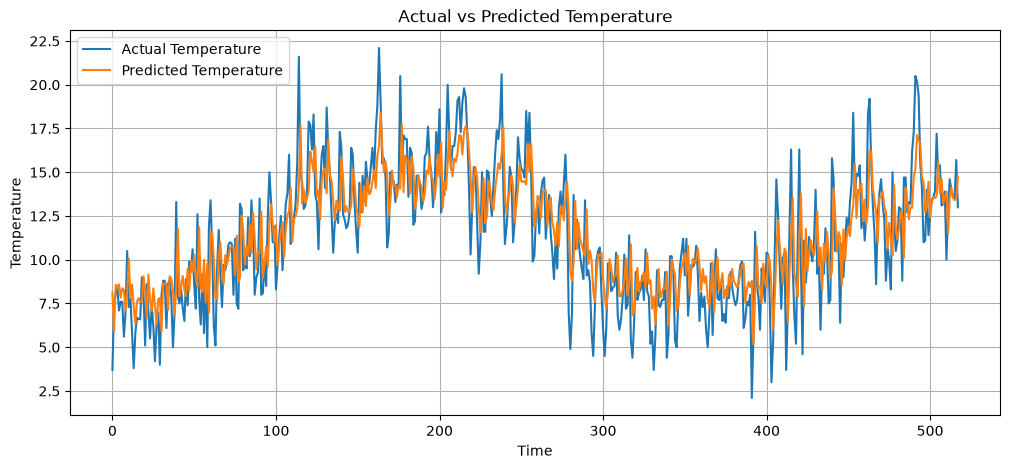

In [34]:
plt.figure(figsize=(12, 5))

plt.plot(
    actuals_actual,
    label="Actual Temperature"
)

plt.plot(
    predictions_actual,
    label="Predicted Temperature"
)

plt.xlabel("Time")
plt.ylabel("Temperature")

plt.title(
    "Actual vs Predicted Temperature"
)

plt.legend()
plt.grid()

plt.show()

In [35]:
import torch
import joblib

# Save model weights
torch.save(
    model.state_dict(),
    "temperature_rnn.pth"
)

# Save scaler
joblib.dump(
    scaler,
    "temperature_scaler.pkl"
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
